In [1]:
import pandas as pd
import numpy as np
import json
import ast

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point
import kaleido

# 1.POI 整体空间分布分析

In [3]:
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False 

In [4]:
new_candidates_gdf=gpd.read_file('new_candidates_gdf.geojson')
geometry_target=gpd.read_parquet('geometry_target.parquet')
geometry_competitor=gpd.read_parquet('geometry_competitor.parquet')

In [5]:
co_analyse_data=pd.read_csv('co_analyse_data.csv')
coffee_data=pd.read_csv('coffee_data.csv')

In [6]:
co_analyse_data.rename(columns={'typ_co_bro':'subclass'},inplace=True)
coffee_data.rename(columns={'typ_co_bro':'subclass'},inplace=True)

In [7]:
replace_map = {5: '咖啡', 6: '购物中心', 12: '办公楼', 15: '地铁出入口'}
co_analyse_data['subclass'] = co_analyse_data['subclass'].replace(replace_map)
coffee_data['subclass'] = coffee_data['subclass'].replace(replace_map)

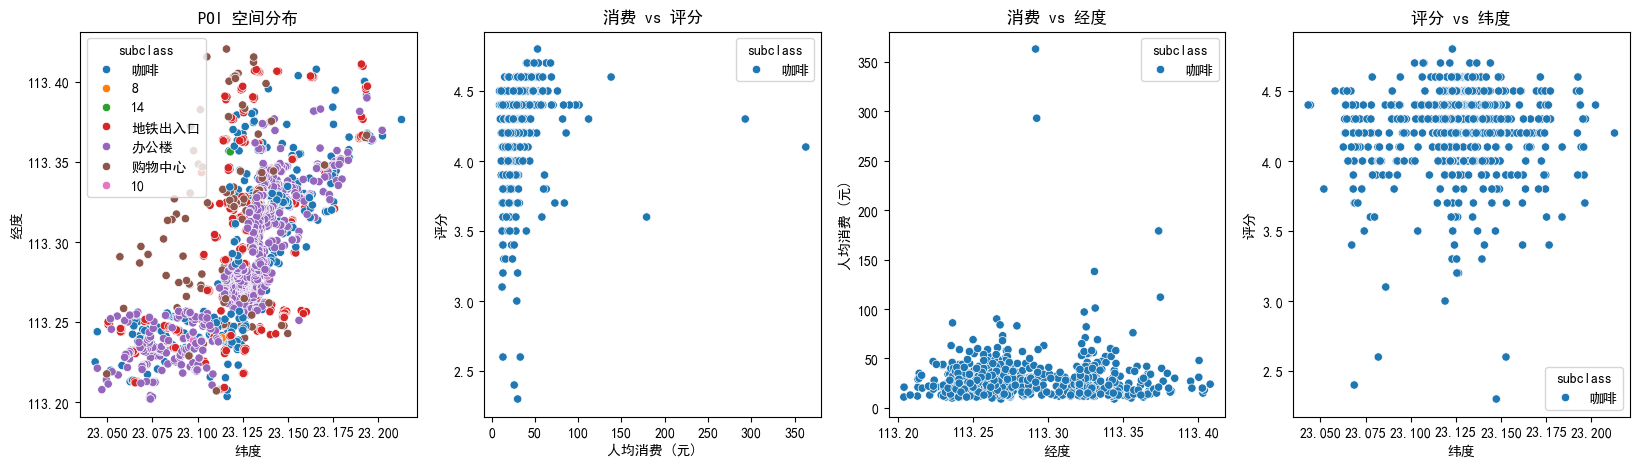

In [8]:
fig,axes=plt.subplots(1,4,figsize=(20,5))
sns.scatterplot(co_analyse_data,x='latitude',y='longitude',hue='subclass',ax=axes[0])
axes[0].set_title('POI 空间分布')
axes[0].set_xlabel('纬度')
axes[0].set_ylabel('经度')
sns.scatterplot(coffee_data,x='cost',y='rating',hue='subclass',ax=axes[1])
axes[1].set_title('消费 vs 评分')
axes[1].set_xlabel('人均消费 (元)')
axes[1].set_ylabel('评分')
sns.scatterplot(coffee_data,x='longitude',y='cost',hue='subclass',ax=axes[2])
axes[2].set_title('消费 vs 经度')
axes[2].set_xlabel('经度')
axes[2].set_ylabel('人均消费 (元)')
sns.scatterplot(coffee_data,x='latitude',y='rating',hue='subclass',ax=axes[3])
axes[3].set_title('评分 vs 纬度')
axes[3].set_xlabel('纬度')
axes[3].set_ylabel('评分')
fig.savefig("广州中心城区 POI 散点图.png", dpi=300, bbox_inches="tight")

**业务洞察**

选址的底层逻辑成立：配套越密集的区域（经度 113.2-113.35、纬度 23.05-23.15，即天河、越秀核心商务区），咖啡门店的分布越密集，验证了「写字楼、商场、地铁是咖啡门店选址的核心配套」的行业常识。
品牌护城河清晰：人均消费越高的门店，评分下限越高，没有低评分的高客单价门店，说明星巴克的品牌溢价有稳定的品质和服务做支撑，高客单价门店的抗风险能力更强。

消费能力的空间差异明确：高消费门店（人均 > 100 元）全部集中在天河东部核心商务区，越靠东的办公区消费能力越强，是高定位门店的核心布局区；而高评分门店集中在越秀 - 天河核心配套区，核心资源区的门店口碑更稳定。

# 2.广州中心城区 POI 密度热力图

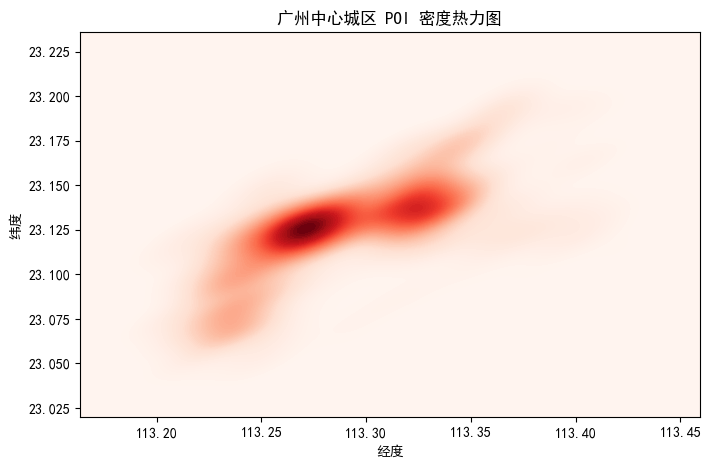

In [9]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=co_analyse_data, x='longitude', y='latitude', cmap='Reds', fill=True, thresh=0, levels=100)
plt.xlabel('经度')
plt.ylabel('纬度')
plt.title('广州中心城区 POI 密度热力图')
plt.show()
fig.savefig("广州中心城区 POI 密度热力图.png", dpi=300, bbox_inches="tight")

**业务洞察**

核心市场高度集中：广州 4 区的咖啡消费核心区呈现「双核心」格局：

主核心区：经度 113.25-113.3、纬度 23.1-23.15（越秀 - 天河交界核心商务区），是全区域密度最高的板块，也是咖啡消费的基本盘；

次核心区：经度 113.3-113.35、纬度 23.12-23.15（天河路 - 珠江新城片区），是第二高密度成熟商圈。

空白市场清晰可寻：经度 113.2 以西（荔湾、海珠西部）、纬度 23.1 以南（海珠南部）的密度极低，属于未被充分开发的市场，是后续开店的核心潜力方向。


In [10]:
gz_central_area=gpd.read_file('gz_central_area.geojson')

In [11]:
gz_central_area=gz_central_area.to_crs('EPSG:32650')

# 3.目标品牌与竞品缓冲区覆盖及高分候选点分布图

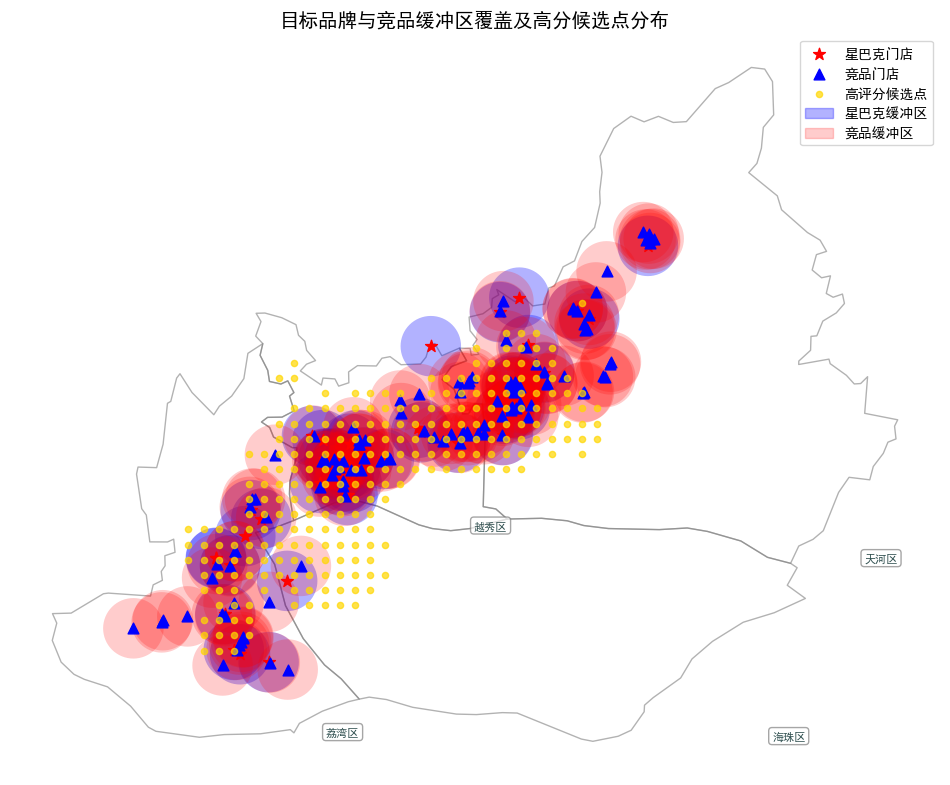

In [12]:
import matplotlib.patches as mpatches

top20=new_candidates_gdf[new_candidates_gdf['new_total_score']>new_candidates_gdf['new_total_score'].quantile(0.8)]
fig,ax=plt.subplots(figsize=(12,10))
gz_central_area.plot(ax=ax, facecolor='none',edgecolor='gray',linewidth=1,alpha=0.6)
geometry_target['buffer'].plot(ax=ax, color='blue', alpha=0.3, edgecolor='none')
geometry_competitor['buffer'].plot(ax=ax, color='red', alpha=0.2, edgecolor='none')
geometry_target.geometry.plot(ax=ax,color='red',marker='*',markersize=80,label='星巴克门店')
geometry_competitor.geometry.plot(ax=ax,color='blue',marker='^',markersize=60,label='竞品门店')
top20.geometry.plot(ax=ax,color='gold',marker='o',markersize=20,alpha=0.7,label='高评分候选点')
starbucks_patch = mpatches.Patch(color='blue', alpha=0.3, label='星巴克缓冲区')
competitor_patch = mpatches.Patch(color='red', alpha=0.2, label='竞品缓冲区')

for idx, row in gz_central_area.iterrows():
    bounds = row.geometry.bounds  
    x, y = bounds[2], bounds[1]  
    ax.text(x, y, row['adname'], fontsize=8, ha='right', va='bottom',
            color='darkslategray', style='italic',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, edgecolor='gray'))
    
handles, labels = ax.get_legend_handles_labels()
handles.extend([starbucks_patch, competitor_patch])
labels.extend(['星巴克缓冲区', '竞品缓冲区'])
ax.legend(handles=handles, loc='upper right')
ax.set_title('目标品牌与竞品缓冲区覆盖及高分候选点分布', fontsize=14)
ax.set_axis_off()
plt.show()
fig.savefig("目标品牌与竞品缓冲区覆盖及高分候选点分布图.png", dpi=300, bbox_inches="tight")

**业务洞察**

竞品全域布局更激进：红色的竞品缓冲区几乎完全覆盖了核心成熟区，门店密度、覆盖范围都远超星巴克，说明瑞幸、库迪已经完成了核心区的密集布局，市场渗透率更高。

核心区竞争高度内卷：成熟商圈的星巴克与竞品缓冲区几乎完全重合，双方都在争抢核心办公 / 商业资源，这里是典型的红海市场，后续布局需要极度谨慎。

模型精准锁定了市场空白：黄色的高分候选点，全部集中在「双空白区」—— 星巴克未覆盖、竞品覆盖也极少的区域，完全符合「低竞争、高资源」的优质选址逻辑，证明
模型能精准识别品牌的拓展机会。

明确了优先拓展方向：经度 113.25 以西、纬度 23.1 以南的区域，有大量高分候选点，且双方覆盖都极少，是品牌未来 1-2 年的核心拓展空白市场。


# 4.候选点综合评分空间分布图

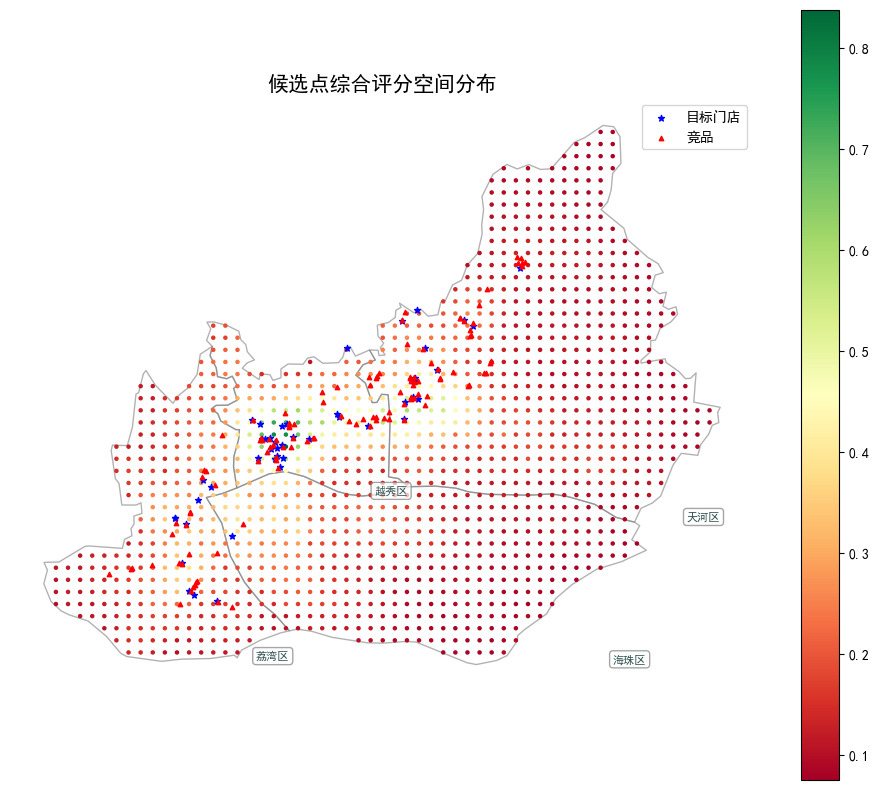

In [13]:
fig,ax=plt.subplots(figsize=(12,10))
gz_central_area.plot(ax=ax, facecolor='none',edgecolor='gray',linewidth=1,alpha=0.6)
new_candidates_gdf.plot(ax=ax,column='new_total_score',cmap='RdYlGn',markersize=5,legend=True)
geometry_target.plot(ax=ax,color='blue', markersize=20, marker='*', label='目标门店')
geometry_competitor.plot(ax=ax, color='red', markersize=10, marker='^', label='竞品')

for idx, row in gz_central_area.iterrows():
    bounds = row.geometry.bounds  
    x, y = bounds[2], bounds[1]  
    ax.text(x, y, row['adname'], fontsize=8, ha='right', va='bottom',
            color='darkslategray', style='italic',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, edgecolor='gray'))

ax.legend()
ax.set_title('候选点综合评分空间分布', fontsize=15)
ax.set_axis_off()  
plt.show()
fig.savefig("候选点综合评分空间分布图.png", dpi=300, bbox_inches="tight")

**业务洞察**

模型完全匹配品牌现有选址逻辑：星巴克现有的门店，90% 以上都落在评分 0.4 以上的中高潜力区域，说明模型完全复现了星巴克成熟的选址标准，具备可复用性。

高潜力区域精准锁定：优质点位集中在两个板块：

越秀西部 - 荔湾东部：核心配套充足，双方门店都极少，是核心城区里的稀缺空白潜力区；

海珠北部：居住人口充足，竞品覆盖少，是社区型门店的优质布局区。

红海区域清晰规避：天河核心区的点位几乎全为红色低评分，这里门店密集、竞争激烈、市场饱和，模型自动规避了这类高风险区域，符合选址的风险控制逻辑。

# 5.候选点评分直方图 + 箱型图

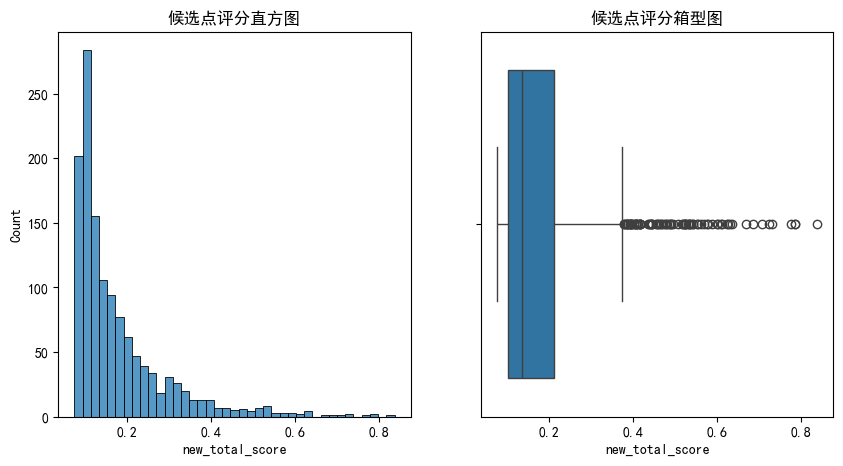

In [14]:
fig,ax=plt.subplots(1,2,figsize=(10,5))
sns.histplot(new_candidates_gdf['new_total_score'],ax=ax[0])
axes[0].set_xlabel('综合评分')
axes[0].set_ylabel('候选点数量')
ax[0].set_title('候选点评分直方图')
sns.boxplot(data=new_candidates_gdf,x='new_total_score',ax=ax[1])
ax[1].set_title('候选点评分箱型图')
plt.show()
fig.savefig("候选点评分直方图和箱型图.png", dpi=300, bbox_inches="tight")

**业务洞察**

符合商业选址的常识：评分呈现明显的右偏分布，80% 以上的候选点评分集中在 0.1-0.3 的低潜力区间，高分点位（>0.5）占比不足 5%，完美验证了「优质开店点位永远是稀缺的」的行业常识，模型的输出符合真实商业逻辑。

模型区分度极强：评分从 0.1 到 0.8 有完整的梯度分布，能有效区分高潜力和低潜力点位，不是所有点位都集中在一个区间，说明设计的指标和权重，能精准识别点位的优劣。

优质点位的稀缺性明确：箱型图显示，评分中位数仅 0.2，只有 25% 的点位评分高于 0.3，最右侧的异常值就是筛选出的 Top 高分点位，这些就是品牌需要争抢的稀缺优质资源。


# 5.Top10 候选点雷达图

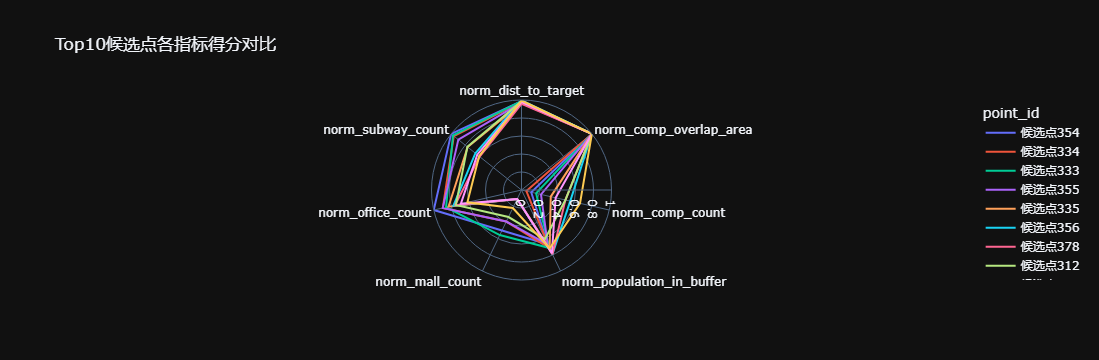

In [15]:
import plotly.express as px

top10 = new_candidates_gdf.sort_values("new_total_score", ascending=False).head(10)

indicator_cols = ['norm_dist_to_target', 'norm_comp_overlap_area', 'norm_comp_count',
                  'norm_population_in_buffer', 'norm_mall_count', 'norm_office_count', 'norm_subway_count']

top10['point_id'] = '候选点' + top10.index.astype(str)

# 转换为长格式，便于 plotly 绘制
df_long = top10.melt(id_vars='point_id', value_vars=indicator_cols, 
                      var_name='指标', value_name='得分')

# 使用 plotly 的平行坐标图绘制雷达图
fig = px.line_polar(df_long, r='得分', theta='指标', line_close=True,
                    color='point_id', template='plotly_dark',
                    title='Top10候选点各指标得分对比')
fig.show()
fig.write_image("Top10候选点各指标得分对比雷达图.png", width=1200, height=800, scale=2)

**业务洞察**

Top 点位的核心优势高度统一：所有点位在「写字楼数量」「常住人口」「地铁口数量」三个核心指标上得分都拉满，完全符合模型的核心逻辑 —— 办公人口、居住人口、可达性是咖啡门店的核心生命线，模型精准筛选出了基础盘达标的优质点位。

竞争维度表现优异：所有点位在「竞品数量」「竞品重叠面积」上的得分都很高，说明这些点位都处于低竞争环境，没有密集的竞品分流，能保障单店的客流和营收效率。

点位差异化清晰，可匹配不同门店定位：

全能型点位（如候选点 354）：所有维度表现均衡，是优先开店的首选；

办公型点位：写字楼指标突出，适合布局核心商务区的工作日高频门店；

社区型点位：常住人口指标突出，适合布局全时段经营的社区门店。


In [16]:
#co_analyse_data.to_csv('co_analyse_data.geojson')
#coffee_data.to_csv('coffee_data.geojson')